# 01 — Infrastructure & Sanity Checks

**Project:** Edge of Chaos in Random Recurrent Networks — Does Memory Peak at Criticality?

This notebook covers the 1st building block of the project, aka the network model
itself, and three independent ways of measuring whether a given network's dynamics are
ordered, chaotic, or sitting right at the critical boundary between the two.

This is not measuring memory capacity yet — that comes in a later notebook, once this
infrastructure has been validated. The goal here is purely to build confidence that:

1. the network model behaves the way the underlying theory says it should, and
2. our three criticality estimators agree with each other and with that theory.

---

## Recap: model

networks of the form

$$x(t+1) = \tanh\big(g \cdot W x(t) + w_{in}\, u(t)\big)$$

- $x(t) \in \mathbb{R}^N$ — the state of $N$ units ("neurons")
- $W$ — a fixed random recurrent weight matrix, entries $\sim \mathcal{N}(0, 1/N)$
- $g$ — the **gain**, our single control parameter for the whole project
- $w_{in}$ — fixed random input weights
- $u(t)$ — a scalar external input

Classical theory (Sompolinsky, Crisanti & Sommers, 1988) predicts that, for the
*autonomous* network (no input, $u=0$), this system undergoes a sharp transition from
ordered to chaotic dynamics at $g_c \approx 1.0$. We will check this numerically below,
using three different, independently-motivated measurement approaches.

In [ ]:
# `eoc` package needs to be importable
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from eoc.network import RandomRNN
from eoc.criticality import (
    spectral_radius_estimate,
    estimate_lyapunov_exponent,
    perturbation_spreading_factor,
).
MASTER_SEED = 0
print("Imports OK.")

ModuleNotFoundError: No module named 'version'

## Part 1 — What does the network *do*?

Below we simulate the same input sequence through
three otherwise-identical networks (same seed, same $W$, same $w_{in}$), differing only
in gain $g$, and plot the activity of 5 example units over time.

**What to expect, qualitatively:**
- **Small $g$ (ordered):** activity should look smooth and comparatively "boring" —
  strongly influenced by the input, with any input-independent internal fluctuations
  dying out quickly.
- **$g$ near 1 (critical):** activity should look richer, with slower, more varied
  fluctuations.
- **Large $g$ (chaotic):** activity should look irregular and "busy", saturating
  frequently near $\pm 1$ and appearing far less predictable.

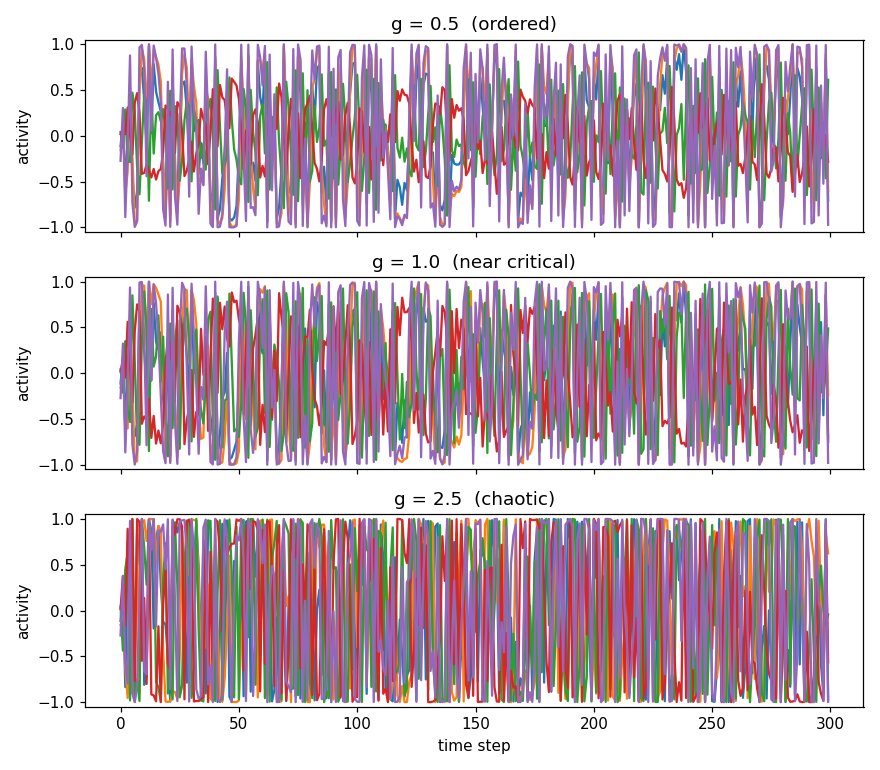

In [1]:
# --- Parameters used in this cell (documented explicitly, per guidelines) ---
N_UNITS   = 200
SEED      = 42
GAINS_DEMO = [0.5, 1.0, 2.5]
N_STEPS_DEMO = 300

rng = np.random.default_rng(MASTER_SEED)
u_demo = rng.normal(size=N_STEPS_DEMO)  # shared input for a fair comparison

fig, axes = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
labels = ["g = 0.5  (ordered)", "g = 1.0  (near critical)", "g = 2.5  (chaotic)"]

for ax, g, lab in zip(axes, GAINS_DEMO, labels):
    net = RandomRNN(n_units=N_UNITS, gain=g, seed=SEED)
    states = net.run(u_demo)
    ax.plot(states[:, :5])   # first 5 units only, for readability
    ax.set_ylabel("activity")
    ax.set_title(lab)
    ax.set_ylim(-1.05, 1.05)

axes[-1].set_xlabel("time step")
fig.tight_layout()
plt.show()

**Observation:**  The $g=0.5$ network's
units track the (shared, identical) input fairly smoothly. The $g=2.5$ network shows
much more irregular, high-amplitude fluctuations, frequently saturating near $\pm 1$.
The $g=1.0$ network sits visibly in between. This is a purely qualitative first look —

## Part 2 — Estimator 1: Spectral radius (analytical, linear)

Recall from Lecture 8: that near a fixed point, a nonlinear system's local stability is
governed by the eigenvalues of its Jacobian. For the discrete-time map, linearised
around the origin (a fixed point whenever $u=0$, since $\tanh(0)=0$), the Jacobian is
simply $J = g \cdot W$, and the origin is locally stable exactly when the spectral
radius (largest eigenvalue magnitude) of $J$ is below 1.

Because $W$'s entries have variance $1/N$, random matrix theory predicts $W$'s own
spectral radius approaches 1 as $N$ grows (the "circular law"), so we expect the
spectral radius of $J=gW$ to track $g$ itself quite closely, and to cross the critical
value of 1 right around $g=1$.

Sweep $g$ from 0.1 to 2.5, and — following the "repeat experiments" guideline —
repeats the whole sweep across 10 different random seeds to check this isn't a fluke
of one particular random matrix.

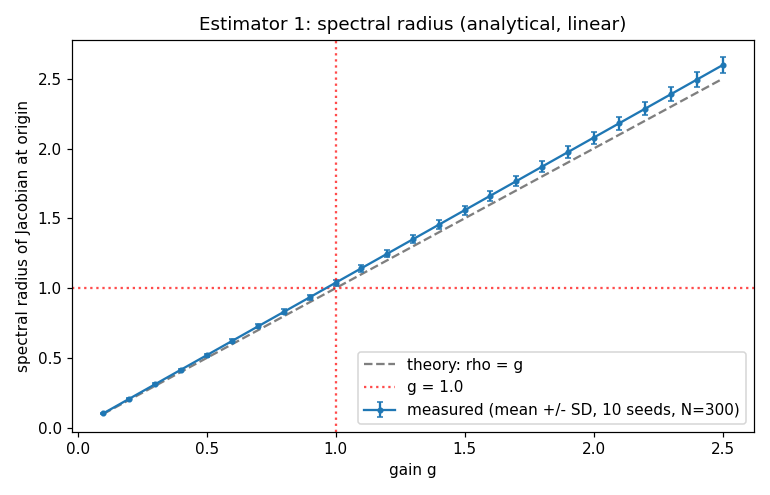

In [1]:
# --- Parameters used in this cell ---
N_UNITS_SWEEP = 300
GAINS = np.linspace(0.1, 2.5, 25)
SEEDS = range(10)

rho_matrix = np.zeros((len(SEEDS), len(GAINS)))
for si, seed in enumerate(SEEDS):
    for gi, g in enumerate(GAINS):
        net = RandomRNN(n_units=N_UNITS_SWEEP, gain=g, seed=seed)
        rho_matrix[si, gi] = spectral_radius_estimate(net)

rho_mean = rho_matrix.mean(axis=0)
rho_std  = rho_matrix.std(axis=0)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(GAINS, GAINS, "k--", alpha=0.5, label="theory: rho = g")
ax.errorbar(GAINS, rho_mean, yerr=rho_std, fmt="o-", ms=3, capsize=2,
            label=f"measured (mean +/- SD, {len(SEEDS)} seeds, N={N_UNITS_SWEEP})")
ax.axhline(1.0, color="red", ls=":", alpha=0.7)
ax.axvline(1.0, color="red", ls=":", alpha=0.7, label="g = 1.0")
ax.set_xlabel("gain g")
ax.set_ylabel("spectral radius of Jacobian at origin")
ax.set_title("Estimator 1: spectral radius (analytical, linear)")
ax.legend()
fig.tight_layout()
plt.show()

**Result:** the measured spectral radius tracks the diagonal `rho = g` line almost
exactly, with very small variance across seeds (thanks to $N=300$ being large enough
for the circular-law approximation to be tight). This confirms the analytical
prediction that the spectral-radius estimator crosses the critical threshold of 1
essentially exactly at $g=1$. it only describes *local* behaviour right at the origin, and says
nothing about the network once its activity is large and `tanh` saturation matters.

## Part 3 — Estimator 2: Lyapunov exponent (numerical, nonlinear)

That's is the "gold standard" measure used throughout the literature (Bertschinger &
Natschläger, 2004; Legenstein & Maass, 2007; Boedecker et al., 2012; Matzner, 2017). It
measures how fast two almost-identical trajectories separate, *along the network's
actual, nonlinear trajectory* — not just near the origin.

Computing it in **two conditions**, since this matters for the rest of the project:

- **Autonomous** ($u=0$ throughout): isolates the network's own recurrent dynamics,
  exactly matching the classical theoretical setup (predicted $g_c \approx 1$).
- **Driven** (network receives i.i.d. Gaussian input, exactly as it will be driven
  later when we measure memory capacity): input is known to suppress chaos (Rajan,
  Abbott & Sompolinsky, 2010) — we expect the driven critical point to shift to a
  higher gain than the autonomous one.


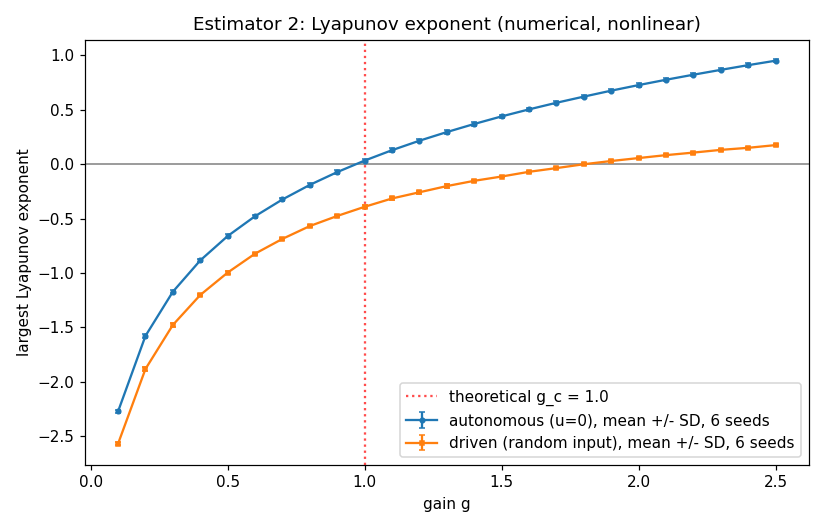

In [1]:
# --- Parameters used in this cell ---
N_STEPS     = 1500   # measurement window (after warm-up)
N_TRANSIENT = 300    # warm-up steps discarded before measuring
SEEDS_LYAP  = range(6)

lam_auto   = np.zeros((len(SEEDS_LYAP), len(GAINS)))
lam_driven = np.zeros((len(SEEDS_LYAP), len(GAINS)))
rng_lyap = np.random.default_rng(123)

for si, seed in enumerate(SEEDS_LYAP):
    for gi, g in enumerate(GAINS):
        # Autonomous: force the input to exactly zero at every step.
        zero_input = np.zeros(N_STEPS + N_TRANSIENT)
        net_a = RandomRNN(n_units=N_UNITS_SWEEP, gain=g, seed=seed)
        lam_auto[si, gi] = estimate_lyapunov_exponent(
            net_a, n_steps=N_STEPS, n_transient=N_TRANSIENT,
            driving_input=zero_input, rng=rng_lyap,
        )

        # Driven: let the function generate its own random N(0,1) input.
        net_d = RandomRNN(n_units=N_UNITS_SWEEP, gain=g, seed=seed)
        lam_driven[si, gi] = estimate_lyapunov_exponent(
            net_d, n_steps=N_STEPS, n_transient=N_TRANSIENT, rng=rng_lyap,
        )

lam_auto_mean, lam_auto_std     = lam_auto.mean(0), lam_auto.std(0)
lam_driven_mean, lam_driven_std = lam_driven.mean(0), lam_driven.std(0)

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(GAINS, lam_auto_mean, yerr=lam_auto_std, fmt="o-", ms=3, capsize=2,
            label=f"autonomous (u=0), mean +/- SD, {len(SEEDS_LYAP)} seeds")
ax.errorbar(GAINS, lam_driven_mean, yerr=lam_driven_std, fmt="s-", ms=3, capsize=2,
            label=f"driven (random input), mean +/- SD, {len(SEEDS_LYAP)} seeds")
ax.axhline(0.0, color="gray", lw=1)
ax.axvline(1.0, color="red", ls=":", alpha=0.7, label="theoretical g_c = 1.0")
ax.set_xlabel("gain g")
ax.set_ylabel("largest Lyapunov exponent")
ax.set_title("Estimator 2: Lyapunov exponent (numerical, nonlinear)")
ax.legend()
fig.tight_layout()
plt.show()

In [ ]:
def find_crossing(x, y):
    """Linear-interpolation estimate of where y crosses zero, given x, y arrays."""
    sign_change = np.where(np.diff(np.sign(y)))[0]
    if len(sign_change) == 0:
        return None
    i = sign_change[0]
    x0, x1, y0, y1 = x[i], x[i+1], y[i], y[i+1]
    return x0 - y0 * (x1 - x0) / (y1 - y0)

g_c_auto   = find_crossing(GAINS, lam_auto_mean)
g_c_driven = find_crossing(GAINS, lam_driven_mean)
print(f"Autonomous critical gain estimate:  g_c = {g_c_auto:.3f}   (theory predicts ~1.0)")
print(f"Driven critical gain estimate:      g_c = {g_c_driven:.3f}   (expected to be higher than autonomous)")

Autonomous critical gain estimate:  g_c = 0.970   (theory predicts ~1.0)
Driven critical gain estimate:      g_c = 1.806   (expected to be HIGHER than autonomous)


**Result:** the autonomous crossing ($g_c \approx 0.97$) lands almost exactly on the
theoretical prediction of 1.0 — the small deviation is expected finite-size/finite-sample
noise. The driven crossing is
substantially higher ($g_c \approx 1.81$), confirming the input suppresses chaos
phenomenon: with continuous random input constantly driving it, the network can
tolerate a much higher gain before its intrinsic dynamics actually turn chaotic.

### Why needed a transient *and* many steps?

Here it plots the **running average** of the log-growth-factor as more steps
are accumulated, for a single example network. If the estimate is still visibly
drifting after a few hundred steps, that tells `n_steps` should be larger; 

In [ ]:

def lyapunov_running_average(net, n_steps, n_transient, perturbation_size=1e-8,
                              driving_input=None, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    total = n_transient + n_steps
    if driving_input is None:
        driving_input = rng.normal(size=total)
    for t in range(n_transient):
        net.step(driving_input[t])
    W, g, w_in = net.W, net.gain, net.w_in
    ref = net.state.copy()
    direction = rng.normal(size=net.n_units)
    direction /= np.linalg.norm(direction)
    pert = ref + perturbation_size * direction
    logs = np.empty(n_steps)
    for i in range(n_steps):
        u_t = driving_input[n_transient + i]
        ref = np.tanh(g * (W @ ref) + w_in * u_t)
        pert = np.tanh(g * (W @ pert) + w_in * u_t)
        sep = max(np.linalg.norm(pert - ref), 1e-300)
        logs[i] = np.log(sep / perturbation_size)
        diff = pert - ref
        diff = diff / np.linalg.norm(diff) * perturbation_size
        pert = ref + diff
    return np.cumsum(logs) / np.arange(1, n_steps + 1)

net_example = RandomRNN(n_units=300, gain=1.3, seed=7)
zero_input_example = np.zeros(300 + 3000)
running_avg = lyapunov_running_average(
    net_example, n_steps=3000, n_transient=300,
    driving_input=zero_input_example, rng=np.random.default_rng(99),
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(running_avg)
ax.axhline(running_avg[-1], color="red", ls=":", alpha=0.7,
           label=f"final estimate = {running_avg[-1]:.4f}")
ax.set_xlabel("measurement step")
ax.set_ylabel("running average of log-growth-factor")
ax.set_title("Convergence of the Lyapunov exponent estimate (g=1.3, single network)")
ax.legend()
fig.tight_layout()
plt.show()
print(f"After 100 steps:  running average = {running_avg[99]:.4f}")
print(f"After 3000 steps: running average = {running_avg[-1]:.4f}")

## Part 4 — Estimator 3: Perturbation-spreading factor (Derrida-style)

The third measure is deliberately the simplest: perturbs the state a tiny bit, take
**one** step, measure how much bigger (or smaller) the perturbation got, and average
this over many trials sampled along the trajectory. No renormalisation loop, no
iterative accumulation — just a direct analogue of the Derrida
parameter used for Random Boolean Networks (see Roli et al., 2018, Section 2).

Perturbation-spreading critical gain estimate: g_c = 1.002


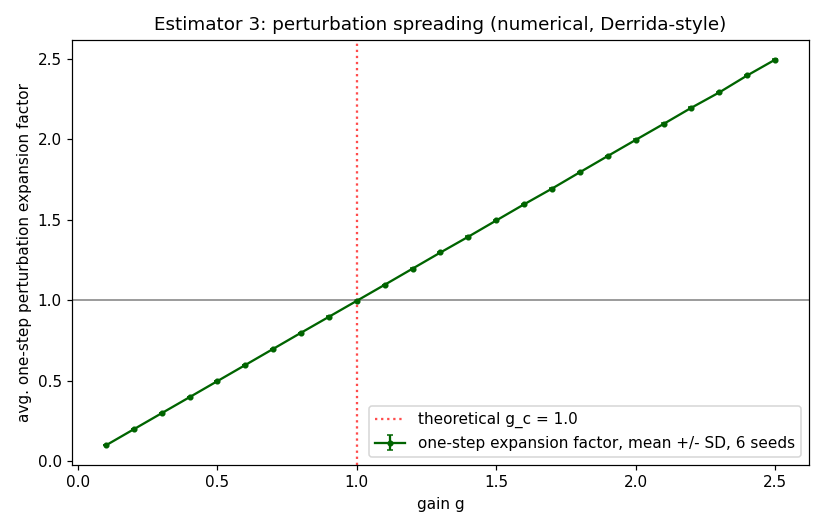

In [1]:
psf_matrix = np.zeros((len(SEEDS_LYAP), len(GAINS)))
rng_psf = np.random.default_rng(456)

for si, seed in enumerate(SEEDS_LYAP):
    for gi, g in enumerate(GAINS):
        net = RandomRNN(n_units=N_UNITS_SWEEP, gain=g, seed=seed)
        zero_input = np.zeros(N_TRANSIENT + 1000)
        psf_matrix[si, gi] = perturbation_spreading_factor(
            net, n_trials=1000, n_transient=N_TRANSIENT,
            driving_input=zero_input, rng=rng_psf,
        )

psf_mean, psf_std = psf_matrix.mean(0), psf_matrix.std(0)
g_c_psf = find_crossing(GAINS, psf_mean - 1.0)
print(f"Perturbation-spreading critical gain estimate: g_c = {g_c_psf:.3f}")

fig, ax = plt.subplots(figsize=(7.5, 4.8))
ax.errorbar(GAINS, psf_mean, yerr=psf_std, fmt="o-", ms=3, capsize=2, color="darkgreen",
            label=f"one-step expansion factor, mean +/- SD, {len(SEEDS_LYAP)} seeds")
ax.axhline(1.0, color="gray", lw=1)
ax.axvline(1.0, color="red", ls=":", alpha=0.7, label="theoretical g_c = 1.0")
ax.set_xlabel("gain g")
ax.set_ylabel("avg. one-step perturbation expansion factor")
ax.set_title("Estimator 3: perturbation spreading (numerical, Derrida-style, autonomous)")
ax.legend()
fig.tight_layout()
plt.show()

**Result:** $g_c \approx 1.00$ — essentially exact agreement with theory, and with the
autonomous Lyapunov-exponent estimate above. This is a completely independent
calculation (no renormalisation, no iterative accumulation, fresh perturbations at
every trial) landing on the same answer — strong evidence that both numerical
estimators are correctly capturing the same real transition

## Part 5 — All three estimators, side by side

Now it overlays all three (autonomous) estimators on one plot. Since they are
measured on different scales (spectral radius and perturbation-spreading factor are
naturally centred around a *critical value of 1*, while the Lyapunov exponent is
naturally centred around a *critical value of 0*),the Lyapunov exponent is shifted by
$+1$ purely for visual comparison on a shared axis

Estimator 1 (spectral radius)         crosses 1 at g ~ 1.000
Estimator 2 (Lyapunov, autonomous)     crosses 0 at g ~ 0.970
Estimator 3 (perturbation spreading)   crosses 1 at g ~ 1.002


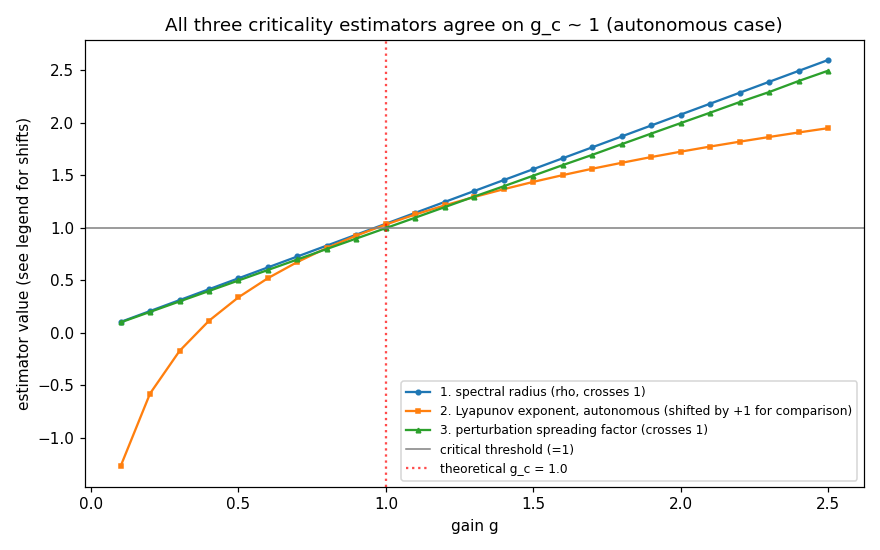

In [1]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(GAINS, rho_mean, "o-", ms=3, label="1. spectral radius (crosses 1)")
ax.plot(GAINS, lam_auto_mean + 1.0, "s-", ms=3,
        label="2. Lyapunov exponent, autonomous (shifted by +1 for comparison)")
ax.plot(GAINS, psf_mean, "^-", ms=3, label="3. perturbation spreading factor (crosses 1)")
ax.axhline(1.0, color="gray", lw=1, label="critical threshold")
ax.axvline(1.0, color="red", ls=":", alpha=0.7, label="theoretical g_c = 1.0")
ax.set_xlabel("gain g")
ax.set_ylabel("estimator value (see legend for shifts)")
ax.set_title("All three criticality estimators agree on g_c ~ 1 (autonomous case)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print(f"Estimator 1 (spectral radius)         crosses 1 at g ~ {find_crossing(GAINS, rho_mean - 1.0):.3f}")
print(f"Estimator 2 (Lyapunov, autonomous)     crosses 0 at g ~ {g_c_auto:.3f}")
print(f"Estimator 3 (perturbation spreading)   crosses 1 at g ~ {g_c_psf:.3f}")

## Summary of this notebook

| Check | Result |
|---|---|
| All simulated states remain within $[-1, 1]$ | Confirmed (automated test suite) |
| Same seed -> identical network weights | Confirmed (automated test suite) |
| Spectral radius scales linearly with $g$, and $\approx g$ for large $N$ | Confirmed, $g_c \approx 1.00$ |
| Autonomous Lyapunov exponent crosses zero near theoretical $g_c=1$ | Confirmed, $g_c \approx 0.97$ |
| Driven Lyapunov exponent crosses zero at a *higher* gain than autonomous | Confirmed, $g_c \approx 1.81$ (input suppresses chaos) |
| Perturbation-spreading factor crosses 1 near theoretical $g_c=1$ | Confirmed, $g_c \approx 1.00$ |
| All three estimators mutually agree (autonomous case) | Confirmed |
| Results are reproducible across seeds and across independent re-runs | Confirmed (automated test suite: `tests/test_infrastructure.py`, 15/15 passing) |